<a href="https://colab.research.google.com/github/michaelsteven1299/proyecto_michael-/blob/main/src/03_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Universidad Libre - Seccional Cali<br>Facultad de Ingeniería - Diplomado en Ciencia de Datos<br>(ↄ) Diego Fernando Marin, 2024

# 03_EDA
Plantilla para el desarrollo del proyecto del diplomado de Ciencia de Datos, aplicando buenas prácticas.

---

Este cuaderno se centra en comprender profundamente los datos mediante análisis estadístico y visualización. El EDA nos permite descubrir patrones, relaciones y características importantes en los datos.

**Propósito:** Obtener insights sobre los datos y preparar el terreno para la selección de características relevantes para el modelado.

**Tareas habituales:**
- Análisis univariante de variables
- Análisis de correlaciones
- Visualización de distribuciones
- Detección de patrones y tendencias
- Análisis de series temporales si aplica
- Identificación de relaciones entre variables
- Generación de hipótesis
- Documentación de insights importantes

**Cada sección debe tener**:
- La Pregunta que se realiza sobre los datos
- El código que genera las tablas o los gráficos donde encontramos la respuesta
- El código que da respuesta a dicha pregunta
- La interpretar del resultado
- Las conclusiones

Análisis Exploratorio

In [1]:

from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

drive.mount('/content/drive')

TRUSTED_PATH = "/content/drive/MyDrive/proyecto_oro/data/trusted/"
df = pd.read_csv(TRUSTED_PATH + "oro_dxy_trusted.csv", parse_dates=['DATE'])

print(f"✅ Dataset cargado: {df.shape}")
df.head()

Mounted at /content/drive
✅ Dataset cargado: (1411, 34)


,DATE,bono_10y_Close,bono_10y_High,bono_10y_Low,bono_10y_Open,bono_10y_Volume,wti_crudo_Close,wti_crudo_High,wti_crudo_Low,wti_crudo_Open,...,vix_Close,vix_High,vix_Low,vix_Open,vix_Volume,oro_xauusd_Close,oro_xauusd_High,oro_xauusd_Low,oro_xauusd_Open,oro_xauusd_Volume
0,2021-01-04,0.917,0.953,0.907,0.935,0.0,47.619999,49.830002,47.180000,48.400002,...,26.969999,29.190001,22.559999,23.040001,0.0,1944.699951,1945.099976,1912.199951,1912.199951,154.0
1,2021-01-05,0.955,0.963,0.927,0.937,0.0,49.930000,50.200001,47.240002,47.380001,...,25.340000,28.600000,24.799999,26.940001,0.0,1952.699951,1952.699951,1941.300049,1941.699951,113.0
2,2021-01-06,1.042,1.054,1.000,1.000,0.0,50.630001,50.939999,49.480000,49.820000,...,25.070000,26.770000,22.139999,25.480000,0.0,1906.900024,1959.900024,1901.500000,1952.000000,331.0
3,2021-01-07,1.071,1.088,1.054,1.056,0.0,50.830002,51.279999,50.389999,50.529999,...,22.370001,23.910000,22.250000,23.670000,0.0,1912.300049,1926.699951,1912.000000,1922.599976,122.0
4,2021-01-08,1.105,1.126,1.075,1.088,0.0,52.240002,52.750000,50.810001,50.930000,...,21.559999,23.340000,21.420000,22.430000,0.0,1834.099976,1908.000000,1834.099976,1908.000000,60.0


ESTADÍSTICAS DESCRIPTIVAS

In [2]:

print("📊 Estadísticas descriptivas — Precios Close:")
cols_close = [c for c in df.columns if 'Close' in c]
df[cols_close].describe().round(2)

📊 Estadísticas descriptivas — Precios Close:


,bono_10y_Close,wti_crudo_Close,plata_xagusd_Close,eur_usd_Close,dxy_Close,vix_Close,oro_xauusd_Close
count,1411.00,1411.00,1411.00,1411.00,1411.00,1411.00,1411.00
mean,3.44,76.71,31.85,1.11,100.81,19.31,2468.88
std,1.13,13.52,16.36,0.06,5.26,5.18,930.23
min,0.92,47.62,17.55,0.96,89.44,11.86,1623.30
25%,2.80,67.43,23.11,1.07,97.74,15.71,1821.40
50%,3.96,74.52,25.46,1.10,101.70,18.06,1982.10
75%,4.28,82.88,32.14,1.16,104.44,21.89,2768.00
max,4.99,123.70,115.08,1.23,114.11,52.33,5318.40


cuanto evoluciono el precio el oro desde el 2021

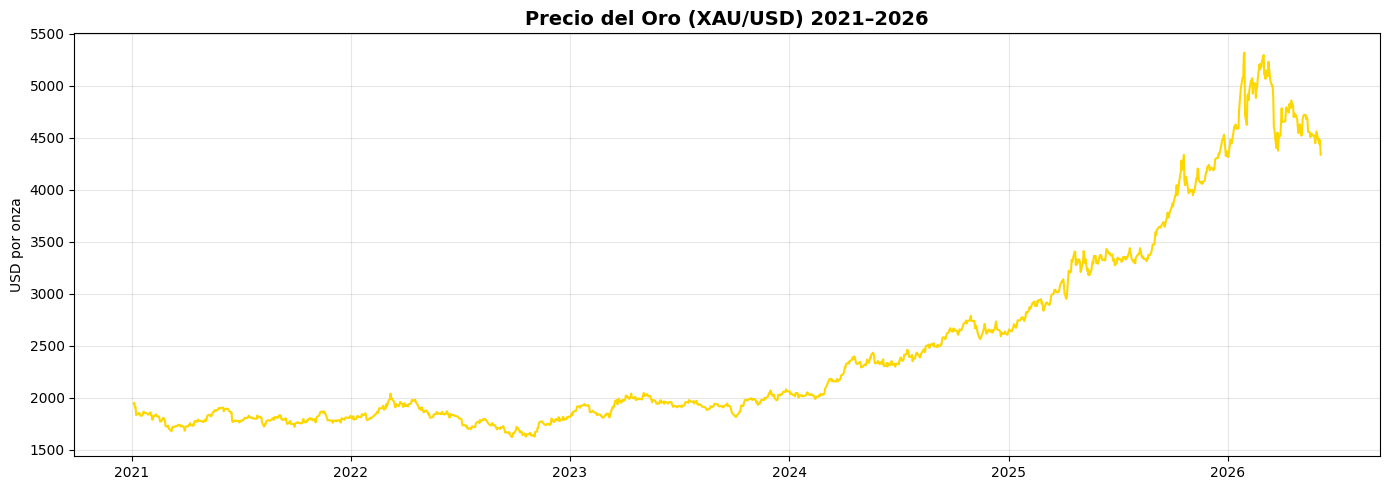

In [3]:

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df['DATE'], df['oro_xauusd_Close'], color='gold', linewidth=1.5)
ax.set_title('Precio del Oro (XAU/USD) 2021–2026', fontsize=14, fontweight='bold')
ax.set_ylabel('USD por onza')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

como evoluciono los demas activos y el oro desde el 2021

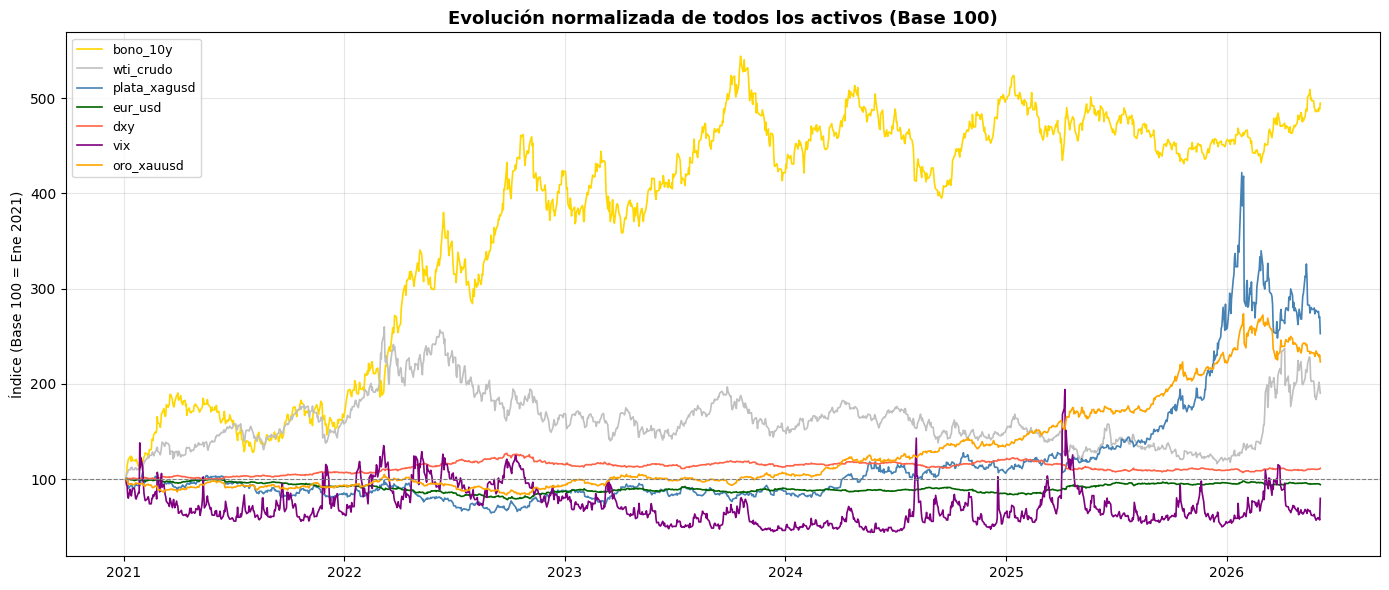

In [4]:

cols_close = [c for c in df.columns if 'Close' in c]
df_norm = df[['DATE'] + cols_close].copy()

for col in cols_close:
    df_norm[col] = df_norm[col] / df_norm[col].iloc[0] * 100

fig, ax = plt.subplots(figsize=(14, 6))
colores = ['gold', 'silver', 'steelblue', 'darkgreen', 'tomato', 'purple', 'orange']

for col, color in zip(cols_close, colores):
    ax.plot(df_norm['DATE'], df_norm[col], label=col.replace('_Close',''),
            linewidth=1.2, color=color)

ax.axhline(100, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Evolución normalizada de todos los activos (Base 100)', fontsize=13, fontweight='bold')
ax.set_ylabel('Índice (Base 100 = Ene 2021)')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

correlacion entre todos los activos

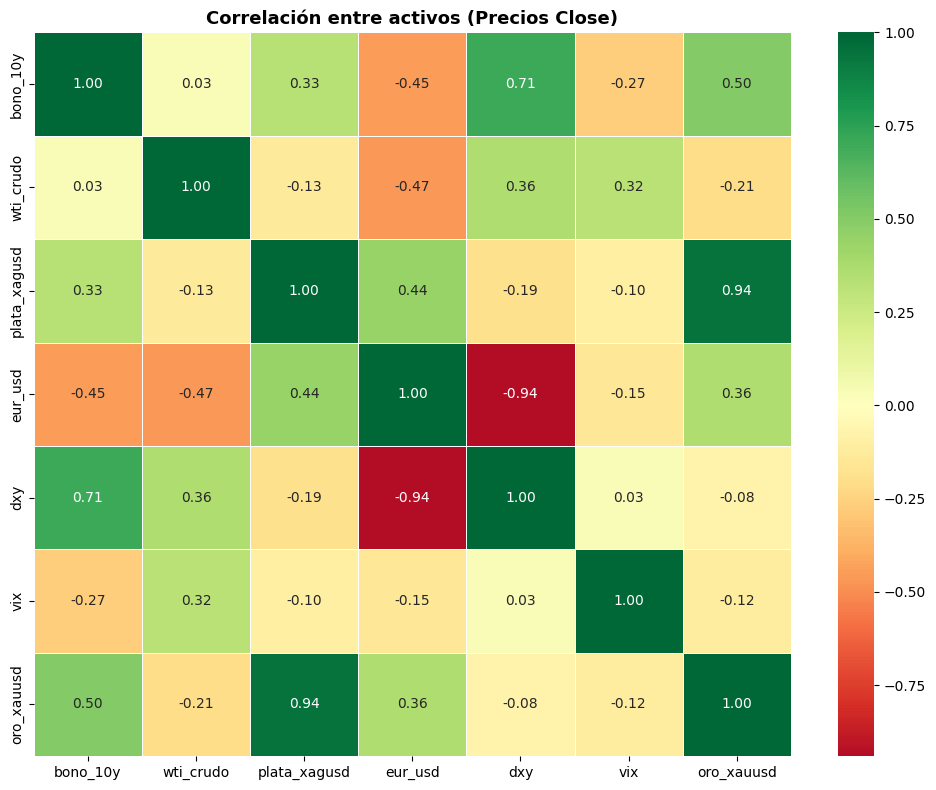

In [6]:

cols_close = [c for c in df.columns if 'Close' in c]
corr = df[cols_close].corr().round(2)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5,
            xticklabels=[c.replace('_Close','') for c in cols_close],
            yticklabels=[c.replace('_Close','') for c in cols_close])
ax.set_title('Correlación entre activos (Precios Close)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

como es la relacion entre el oro y el indice del dolar

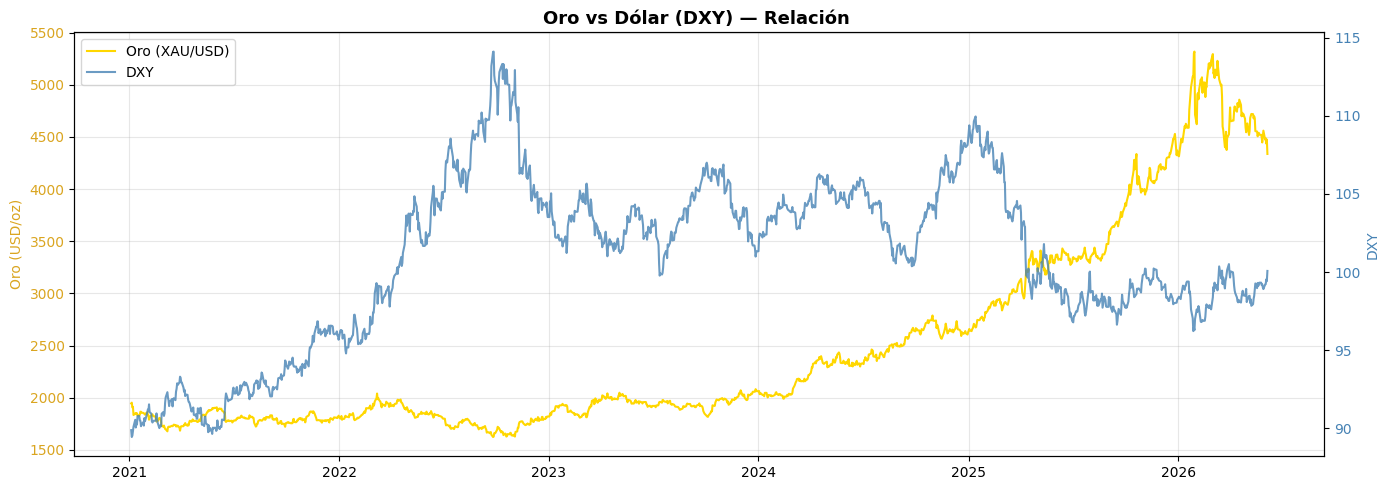

In [21]:

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(df['DATE'], df['oro_xauusd_Close'], color='gold',
         linewidth=1.5, label='Oro (XAU/USD)')
ax1.set_ylabel('Oro (USD/oz)', color='goldenrod')
ax1.tick_params(axis='y', labelcolor='goldenrod')

ax2 = ax1.twinx()
ax2.plot(df['DATE'], df['dxy_Close'], color='steelblue',
         linewidth=1.5, label='DXY', alpha=0.8)
ax2.set_ylabel('DXY', color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

ax1.set_title('Oro vs Dólar (DXY) — Relación ', fontsize=13, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# 8. RESUMEN FINAL DEL EDA
# ============================================================
print("=" * 50)
print("RESUMEN EDA")
print("=" * 50)
print(f"Período:            {df['DATE'].min().date()} → {df['DATE'].max().date()}")
print(f"Días de mercado:    {len(df):,}")
print(f"Activos analizados: {len(cols_close)}")
print(f"\nPrecio oro mínimo:  ${df['oro_xauusd_Close'].min():,.0f}")
print(f"Precio oro máximo:  ${df['oro_xauusd_Close'].max():,.0f}")
print(f"Precio oro actual:  ${df['oro_xauusd_Close'].iloc[-1]:,.0f}")
print(f"\nCorrelación Oro-DXY:   {df['oro_xauusd_Close'].corr(df['dxy_Close']):.3f}")
print(f"Correlación Oro-Plata: {df['oro_xauusd_Close'].corr(df['plata_xagusd_Close']):.3f}")
print(f"Correlación Oro-VIX:   {df['oro_xauusd_Close'].corr(df['vix_Close']):.3f}")

RESUMEN EDA
Período:            2021-01-04 → 2026-06-05
Días de mercado:    1,411
Activos analizados: 7

Precio oro mínimo:  $1,623
Precio oro máximo:  $5,318
Precio oro actual:  $4,337

Correlación Oro-DXY:   -0.078
Correlación Oro-Plata: 0.936
Correlación Oro-VIX:   -0.117


¿Cuál fue el mejor y peor mes del oro?

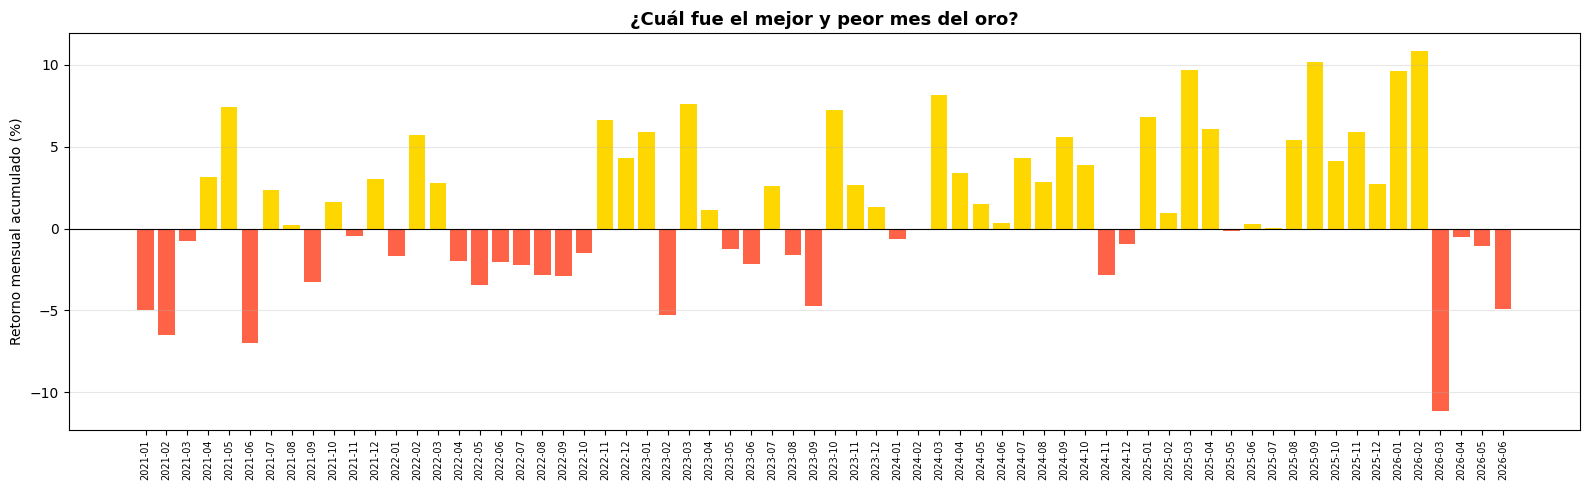

✅ Mejor mes: 2026-02 → 10.85%
❌ Peor mes:  2026-03  → -11.17%


In [10]:

df['mes_año'] = df['DATE'].dt.to_period('M')
retorno_mensual = df.groupby('mes_año')['oro_retorno_1d'].sum().reset_index()
retorno_mensual.columns = ['mes', 'retorno_mensual']

mejor_mes = retorno_mensual.loc[retorno_mensual['retorno_mensual'].idxmax()]
peor_mes  = retorno_mensual.loc[retorno_mensual['retorno_mensual'].idxmin()]

fig, ax = plt.subplots(figsize=(16, 5))
colores = ['tomato' if r < 0 else 'gold' for r in retorno_mensual['retorno_mensual']]
ax.bar(retorno_mensual['mes'].astype(str), retorno_mensual['retorno_mensual'], color=colores)
ax.set_title('¿Cuál fue el mejor y peor mes del oro?', fontsize=13, fontweight='bold')
ax.set_ylabel('Retorno mensual acumulado (%)')
ax.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=90, fontsize=7)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"✅ Mejor mes: {mejor_mes['mes']} → {mejor_mes['retorno_mensual']:.2f}%")
print(f"❌ Peor mes:  {peor_mes['mes']}  → {peor_mes['retorno_mensual']:.2f}%")

# ¿En qué día de la semana sube más el oro?

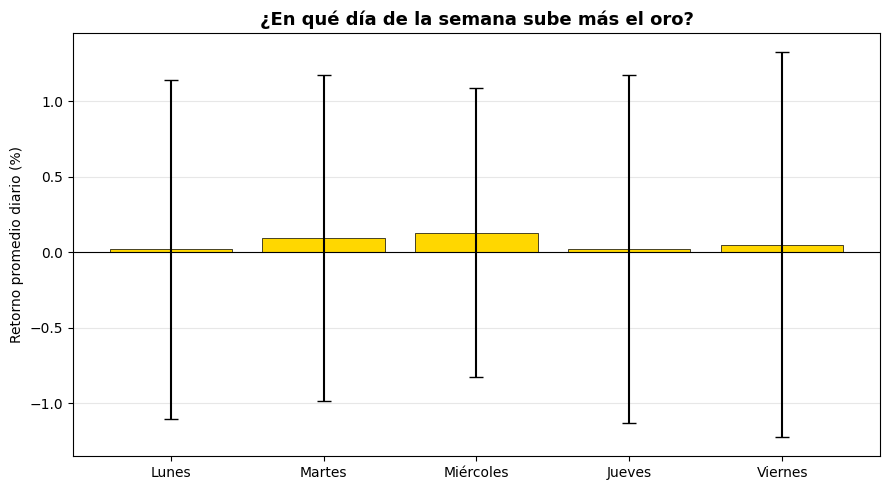

              mean     std
dia_semana                
Lunes       0.0206  1.1229
Martes      0.0922  1.0788
Miércoles   0.1301  0.9554
Jueves      0.0220  1.1528
Viernes     0.0510  1.2744


In [11]:

dias = {0:'Lunes', 1:'Martes', 2:'Miércoles', 3:'Jueves', 4:'Viernes'}
df['dia_semana'] = df['DATE'].dt.dayofweek.map(dias)

retorno_dia = df.groupby('dia_semana')['oro_retorno_1d'].agg(['mean','std']).reindex(
    ['Lunes','Martes','Miércoles','Jueves','Viernes'])

fig, ax = plt.subplots(figsize=(9, 5))
colores = ['gold' if v > 0 else 'tomato' for v in retorno_dia['mean']]
bars = ax.bar(retorno_dia.index, retorno_dia['mean'], color=colores,
              yerr=retorno_dia['std'], capsize=5, edgecolor='black', linewidth=0.5)
ax.set_title('¿En qué día de la semana sube más el oro?', fontsize=13, fontweight='bold')
ax.set_ylabel('Retorno promedio diario (%)')
ax.axhline(0, color='black', linewidth=0.8)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(retorno_dia.round(4))

¿En qué mes del año el oro rinde mejor históricamente?

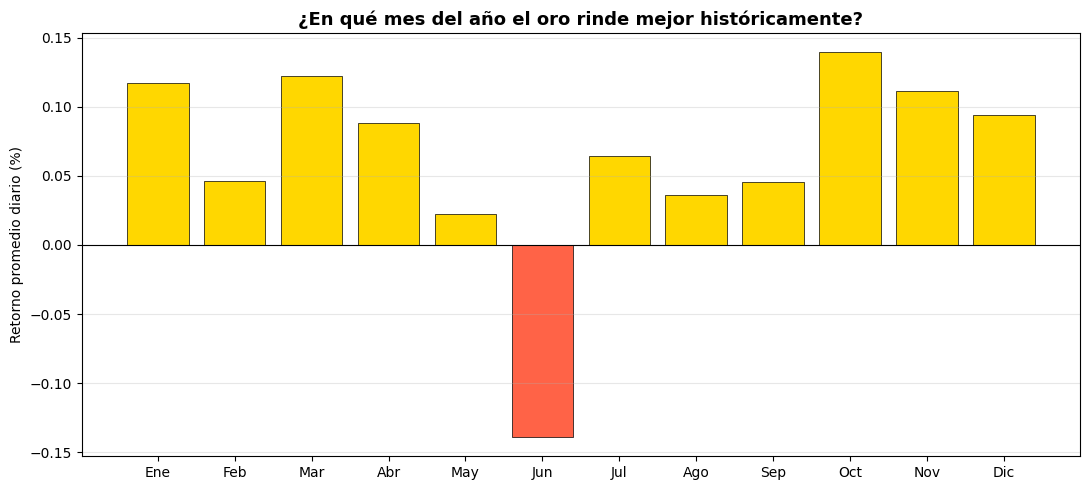

In [12]:

meses = {1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',
         7:'Jul',8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic'}
df['mes_num'] = df['DATE'].dt.month
df['mes_nombre'] = df['mes_num'].map(meses)

retorno_mes = df.groupby('mes_num')['oro_retorno_1d'].mean()
retorno_mes.index = retorno_mes.index.map(meses)

fig, ax = plt.subplots(figsize=(11, 5))
colores = ['gold' if v > 0 else 'tomato' for v in retorno_mes]
ax.bar(retorno_mes.index, retorno_mes, color=colores, edgecolor='black', linewidth=0.5)
ax.set_title('¿En qué mes del año el oro rinde mejor históricamente?',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Retorno promedio diario (%)')
ax.axhline(0, color='black', linewidth=0.8)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

¿Cuándo el dólar sube, el oro baja?

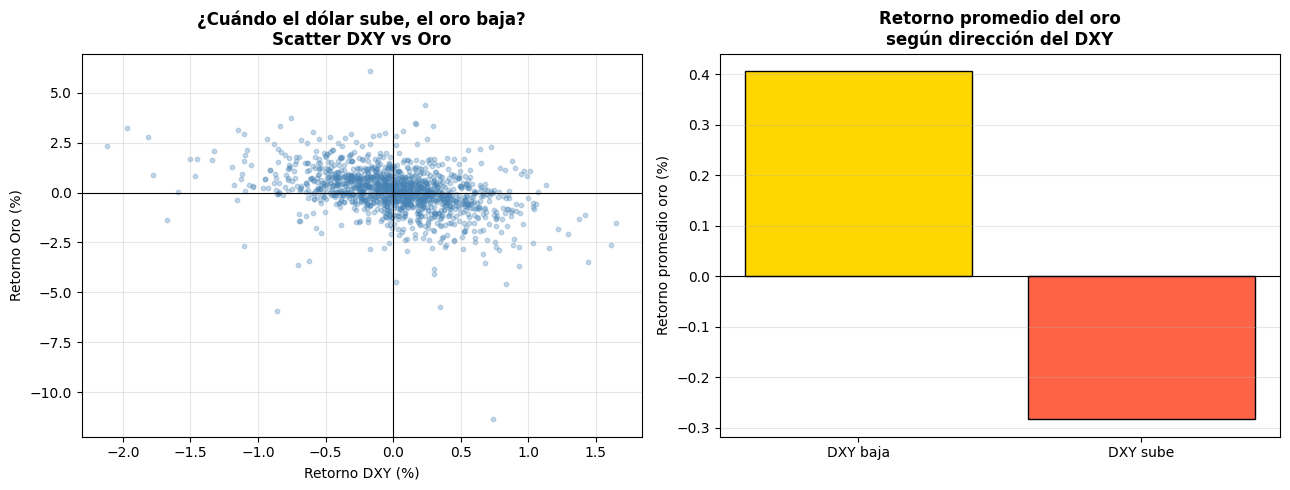

Correlación DXY vs Oro: -0.394
Retorno oro cuando DXY sube: -0.2831%
Retorno oro cuando DXY baja: 0.4066%


In [13]:

df['dxy_retorno'] = df['dxy_Close'].pct_change() * 100
df['dxy_sube']    = df['dxy_retorno'] > 0

retorno_oro_vs_dxy = df.groupby('dxy_sube')['oro_retorno_1d'].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter
axes[0].scatter(df['dxy_retorno'], df['oro_retorno_1d'],
                alpha=0.3, color='steelblue', s=10)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Retorno DXY (%)')
axes[0].set_ylabel('Retorno Oro (%)')
axes[0].set_title('¿Cuándo el dólar sube, el oro baja?\nScatter DXY vs Oro', fontweight='bold')
axes[0].grid(alpha=0.3)

# Barras
etiquetas = ['DXY baja', 'DXY sube']
valores   = [retorno_oro_vs_dxy[False], retorno_oro_vs_dxy[True]]
colores   = ['gold', 'tomato']
axes[1].bar(etiquetas, valores, color=colores, edgecolor='black')
axes[1].set_title('Retorno promedio del oro\nsegún dirección del DXY', fontweight='bold')
axes[1].set_ylabel('Retorno promedio oro (%)')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

corr = df['dxy_retorno'].corr(df['oro_retorno_1d'])
print(f"Correlación DXY vs Oro: {corr:.3f}")
print(f"Retorno oro cuando DXY sube: {retorno_oro_vs_dxy[True]:.4f}%")
print(f"Retorno oro cuando DXY baja: {retorno_oro_vs_dxy[False]:.4f}%")

¿El oro sube cuando hay miedo en el mercado (VIX alto)?

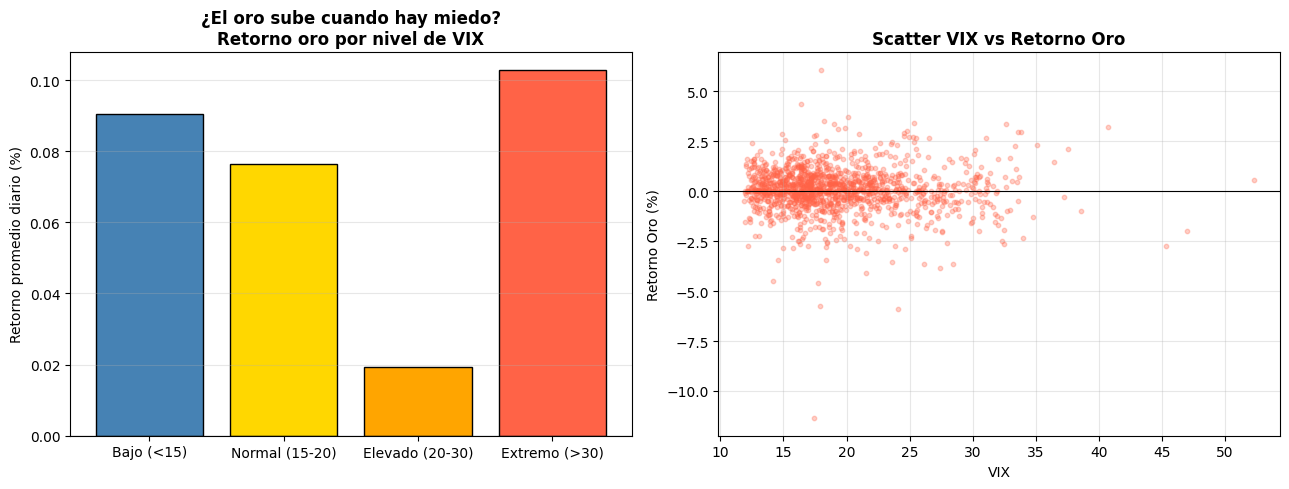

vix_nivel
Bajo (<15)         0.0904
Normal (15-20)     0.0765
Elevado (20-30)    0.0194
Extremo (>30)      0.1027
Name: oro_retorno_1d, dtype: float64


In [14]:

df['vix_nivel'] = pd.cut(df['vix_Close'],
                          bins=[0, 15, 20, 30, 100],
                          labels=['Bajo (<15)', 'Normal (15-20)',
                                  'Elevado (20-30)', 'Extremo (>30)'])

retorno_vix = df.groupby('vix_nivel', observed=True)['oro_retorno_1d'].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colores = ['steelblue', 'gold', 'orange', 'tomato']
axes[0].bar(retorno_vix.index, retorno_vix, color=colores, edgecolor='black')
axes[0].set_title('¿El oro sube cuando hay miedo?\nRetorno oro por nivel de VIX', fontweight='bold')
axes[0].set_ylabel('Retorno promedio diario (%)')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].grid(alpha=0.3, axis='y')

axes[1].scatter(df['vix_Close'], df['oro_retorno_1d'],
                alpha=0.3, color='tomato', s=10)
axes[1].set_xlabel('VIX')
axes[1].set_ylabel('Retorno Oro (%)')
axes[1].set_title('Scatter VIX vs Retorno Oro', fontweight='bold')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(retorno_vix.round(4))

¿Cuáles fueron los 10 mejores y peores días del oro?

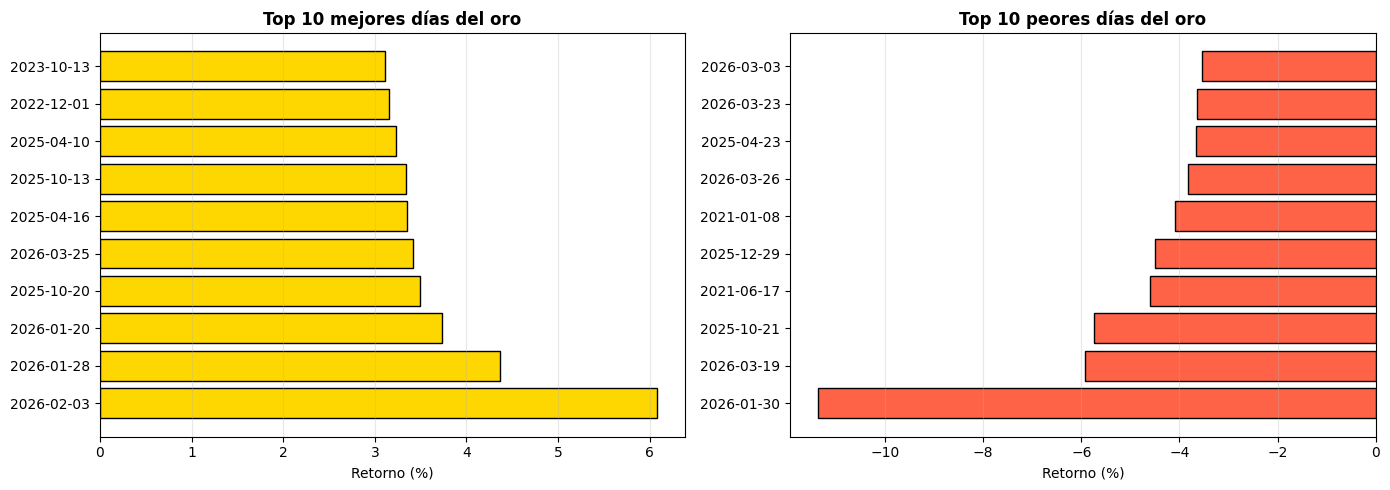

 Mejores días:
      DATE  oro_retorno_1d  vix_Close  dxy_Close
2026-02-03        6.083292  18.000000  97.440002
2026-01-28        4.364263  16.350000  96.449997
2026-01-20        3.731152  20.090000  98.639999
2025-10-20        3.496504  18.230000  98.589996
2026-03-25        3.420999  25.330000  99.599998
2025-04-16        3.352290  32.639999  99.379997
2025-10-13        3.337614  19.030001  99.269997
2025-04-10        3.229182  40.720001 100.870003
2022-12-01        3.155783  19.840000 104.730003
2023-10-13        3.108114  19.320000 106.650002

 Peores días:
      DATE  oro_retorno_1d  vix_Close  dxy_Close
2026-01-30      -11.366201  17.440001  96.989998
2026-03-19       -5.914226  24.059999  99.230003
2025-10-21       -5.735171  17.870001  98.930000
2021-06-17       -4.608763  17.750000  91.889999
2025-12-29       -4.504206  14.200000  98.040001
2021-01-08       -4.089320  21.559999  90.099998
2026-03-26       -3.830933  27.440001  99.900002
2025-04-23       -3.660903  28.450001  

In [22]:

top10_mejores = df.nlargest(10, 'oro_retorno_1d')[['DATE','oro_retorno_1d','vix_Close','dxy_Close']]
top10_peores  = df.nsmallest(10, 'oro_retorno_1d')[['DATE','oro_retorno_1d','vix_Close','dxy_Close']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top10_mejores['DATE'].dt.strftime('%Y-%m-%d'),
             top10_mejores['oro_retorno_1d'], color='gold', edgecolor='black')
axes[0].set_title('Top 10 mejores días del oro', fontweight='bold')
axes[0].set_xlabel('Retorno (%)')
axes[0].grid(alpha=0.3, axis='x')

axes[1].barh(top10_peores['DATE'].dt.strftime('%Y-%m-%d'),
             top10_peores['oro_retorno_1d'], color='tomato', edgecolor='black')
axes[1].set_title('Top 10 peores días del oro', fontweight='bold')
axes[1].set_xlabel('Retorno (%)')
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print(" Mejores días:")
print(top10_mejores.to_string(index=False))
print("\n Peores días:")
print(top10_peores.to_string(index=False))

el oro tiene tendencia alicista en el largo plazo ?

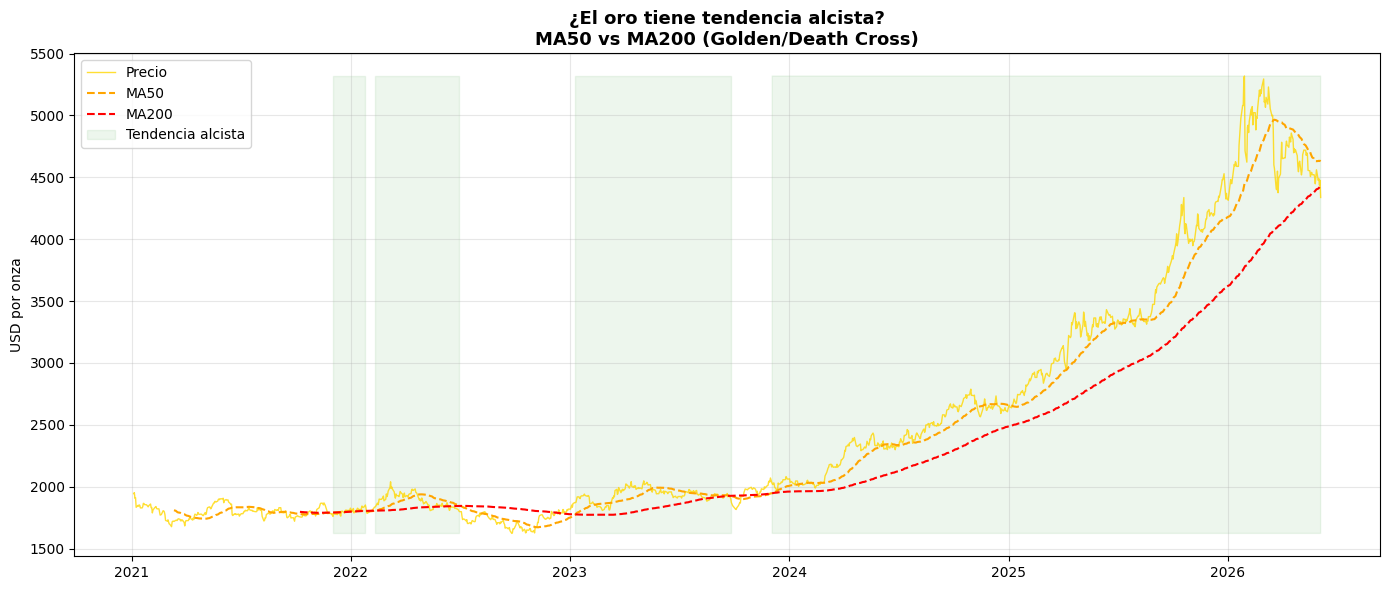

Retorno total del período: 123.0%


In [16]:

df['ma50']  = df['oro_xauusd_Close'].rolling(50).mean()
df['ma200'] = df['oro_xauusd_Close'].rolling(200).mean()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df['DATE'], df['oro_xauusd_Close'], color='gold',
        linewidth=1, label='Precio', alpha=0.8)
ax.plot(df['DATE'], df['ma50'],  color='orange',
        linewidth=1.5, label='MA50', linestyle='--')
ax.plot(df['DATE'], df['ma200'], color='red',
        linewidth=1.5, label='MA200', linestyle='--')

# Golden cross / Death cross
golden = df[df['ma50'] > df['ma200']]
ax.fill_between(df['DATE'], df['oro_xauusd_Close'].min(),
                df['oro_xauusd_Close'].max(),
                where=df['ma50'] > df['ma200'],
                alpha=0.07, color='green', label='Tendencia alcista')

ax.set_title('¿El oro tiene tendencia alcista?\nMA50 vs MA200 (Golden/Death Cross)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('USD por onza')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

retorno_total = (df['oro_xauusd_Close'].iloc[-1] / df['oro_xauusd_Close'].iloc[0] - 1) * 100
print(f"Retorno total del período: {retorno_total:.1f}%")

 ¿Qué tan seguido el oro sube vs baja?


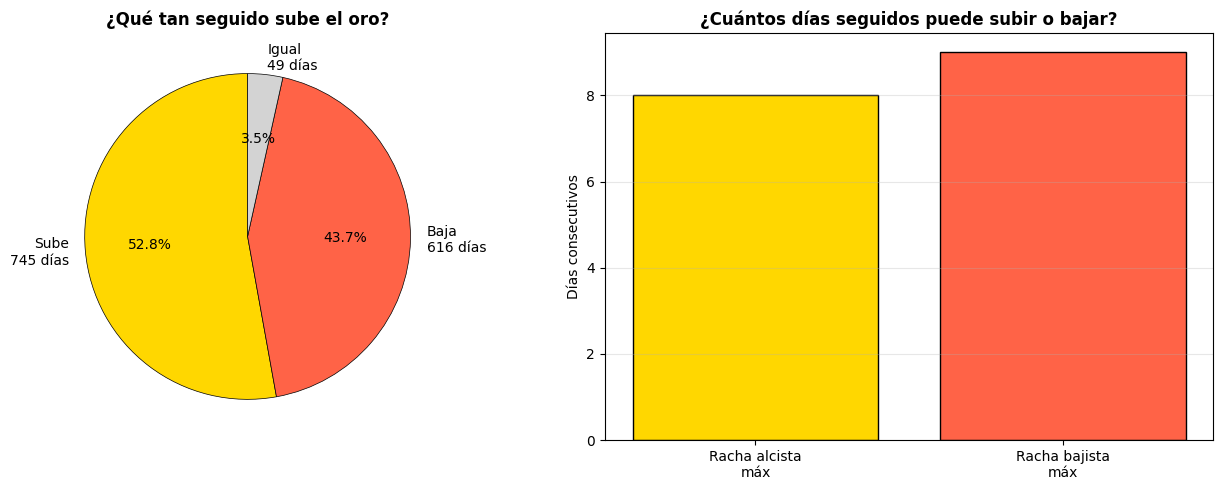

Días que subió:  745 (52.8%)
Días que bajó:   616 (43.7%)
Racha alcista máxima: 8 días consecutivos
Racha bajista máxima: 9 días consecutivos


In [17]:
# ¿Qué tan seguido el oro sube vs baja?
# ============================================================
sube = (df['oro_retorno_1d'] > 0).sum()
baja = (df['oro_retorno_1d'] < 0).sum()
igual= (df['oro_retorno_1d'] == 0).sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].pie([sube, baja, igual],
            labels=[f'Sube\n{sube} días', f'Baja\n{baja} días', f'Igual\n{igual} días'],
            colors=['gold', 'tomato', 'lightgray'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'black', 'linewidth':0.5})
axes[0].set_title('¿Qué tan seguido sube el oro?', fontweight='bold')

# Racha máxima alcista y bajista
df['sube_bin'] = (df['oro_retorno_1d'] > 0).astype(int)
racha = 0
max_racha_sube = 0
for v in df['sube_bin']:
    racha = racha + 1 if v == 1 else 0
    max_racha_sube = max(max_racha_sube, racha)

racha = 0
max_racha_baja = 0
for v in df['sube_bin']:
    racha = racha + 1 if v == 0 else 0
    max_racha_baja = max(max_racha_baja, racha)

axes[1].bar(['Racha alcista\nmáx', 'Racha bajista\nmáx'],
            [max_racha_sube, max_racha_baja],
            color=['gold', 'tomato'], edgecolor='black')
axes[1].set_title('¿Cuántos días seguidos puede subir o bajar?', fontweight='bold')
axes[1].set_ylabel('Días consecutivos')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"Días que subió:  {sube} ({sube/len(df)*100:.1f}%)")
print(f"Días que bajó:   {baja} ({baja/len(df)*100:.1f}%)")
print(f"Racha alcista máxima: {max_racha_sube} días consecutivos")
print(f"Racha bajista máxima: {max_racha_baja} días consecutivos")

# ¿Cómo se comporta el oro en crisis vs calma?

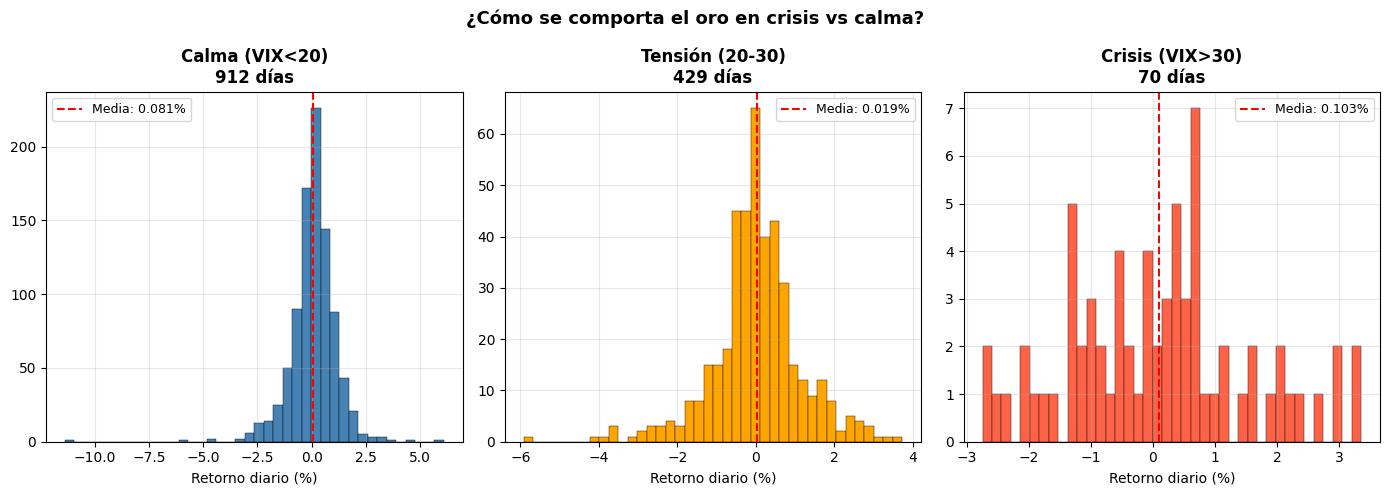

In [18]:

df['regimen'] = pd.cut(df['vix_Close'],
                        bins=[0, 20, 30, 100],
                        labels=['Calma (VIX<20)', 'Tensión (20-30)', 'Crisis (VIX>30)'])

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, (regimen, grupo) in enumerate(df.groupby('regimen', observed=True)):
    colores_reg = ['steelblue', 'orange', 'tomato']
    axes[i].hist(grupo['oro_retorno_1d'].dropna(), bins=40,
                 color=colores_reg[i], edgecolor='black', linewidth=0.3)
    axes[i].set_title(f'{regimen}\n{len(grupo)} días', fontweight='bold')
    axes[i].set_xlabel('Retorno diario (%)')
    axes[i].axvline(grupo['oro_retorno_1d'].mean(), color='red',
                    linestyle='--', label=f"Media: {grupo['oro_retorno_1d'].mean():.3f}%")
    axes[i].legend(fontsize=9)
    axes[i].grid(alpha=0.3)

plt.suptitle('¿Cómo se comporta el oro en crisis vs calma?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

¿Existe relación entre el precio del petróleo y el oro?

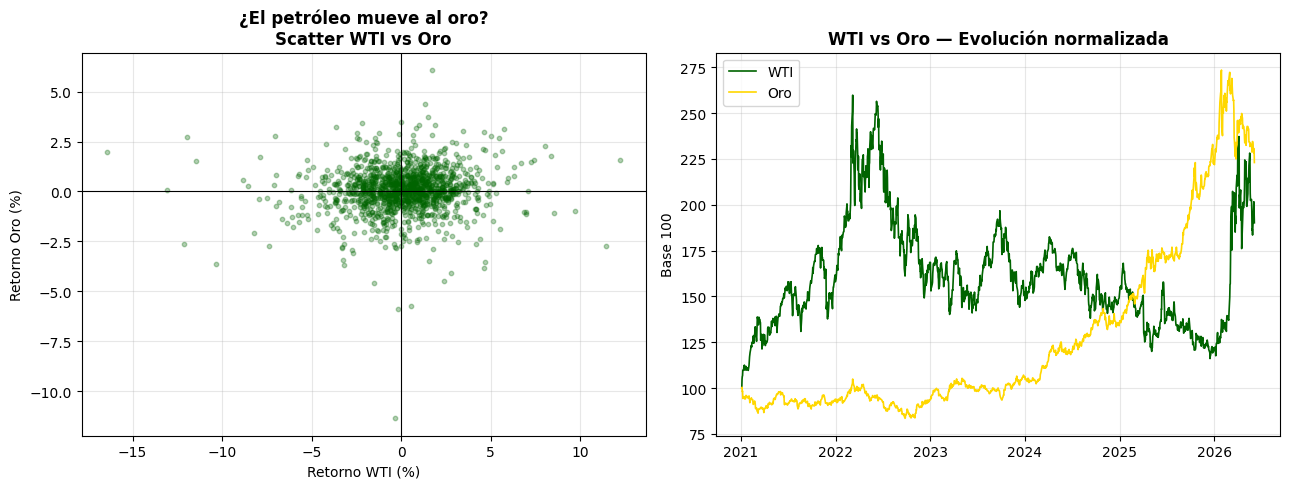

Correlación WTI vs Oro: 0.080


In [19]:

df['wti_retorno'] = df['wti_crudo_Close'].pct_change() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df['wti_retorno'], df['oro_retorno_1d'],
                alpha=0.3, color='darkgreen', s=10)
axes[0].set_xlabel('Retorno WTI (%)')
axes[0].set_ylabel('Retorno Oro (%)')
axes[0].set_title('¿El petróleo mueve al oro?\nScatter WTI vs Oro', fontweight='bold')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].grid(alpha=0.3)

axes[1].plot(df['DATE'], df['wti_crudo_Close'] / df['wti_crudo_Close'].iloc[0] * 100,
             color='darkgreen', label='WTI', linewidth=1.2)
axes[1].plot(df['DATE'], df['oro_xauusd_Close'] / df['oro_xauusd_Close'].iloc[0] * 100,
             color='gold', label='Oro', linewidth=1.2)
axes[1].set_title('WTI vs Oro — Evolución normalizada', fontweight='bold')
axes[1].set_ylabel('Base 100')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

corr = df['wti_retorno'].corr(df['oro_retorno_1d'])
print(f"Correlación WTI vs Oro: {corr:.3f}")

¿Cuál activo fue más rentable en el período?

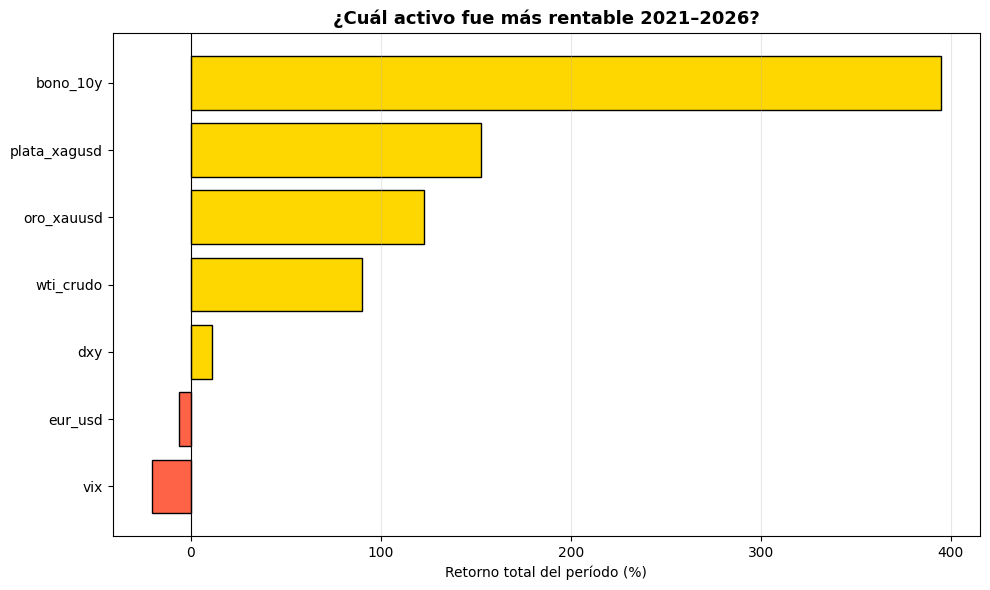

              Retorno_Total_%
vix                    -20.24
eur_usd                 -5.90
dxy                     11.34
wti_crudo               90.13
oro_xauusd             123.02
plata_xagusd           152.69
bono_10y               394.66


In [20]:

cols_close = [c for c in df.columns if '_Close' in c]
rentabilidad = {}

for col in cols_close:
    serie = df[col].dropna()
    if len(serie) > 0:
        ret = (serie.iloc[-1] / serie.iloc[0] - 1) * 100
        rentabilidad[col.replace('_Close', '')] = ret

rent_df = pd.DataFrame.from_dict(rentabilidad, orient='index',
                                   columns=['Retorno_Total_%'])
rent_df = rent_df.sort_values('Retorno_Total_%', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colores = ['gold' if v > 0 else 'tomato' for v in rent_df['Retorno_Total_%']]
ax.barh(rent_df.index, rent_df['Retorno_Total_%'], color=colores, edgecolor='black')
ax.set_title('¿Cuál activo fue más rentable 2021–2026?', fontsize=13, fontweight='bold')
ax.set_xlabel('Retorno total del período (%)')
ax.axvline(0, color='black', linewidth=0.8)
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print(rent_df.round(2))